# LSTM Temporal Model

This notebook implements an LSTM model for Taxi-Out prediction.


Dataset shape : (339013, 26)
   month  day_of_month  scheduled_departure_time  scheduled_arrival_time  \
0      1             4                       400                     479   
1      1             4                       360                     434   
2      1             4                       400                     545   
3      1             4                       375                     488   
4      1             4                       440                     514   

  unique_carrier  flight_number  scheduled_elapsed_time  departure_delay  \
0             XE           2348                    79.0             -7.0   
1             YV           7331                   134.0             15.0   
2             OH           4999                   145.0             50.0   
3             OH           5303                   113.0             15.0   
4             OO           5873                   134.0              0.0   

  origin dest  ...  day  day_of_week_num  is_weekend  dep

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 0.8633 - mae: 0.5228 - val_loss: 1.1858 - val_mae: 0.5971 - learning_rate: 0.0010
Epoch 2/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.8579 - mae: 0.5197 - val_loss: 1.1908 - val_mae: 0.6028 - learning_rate: 0.0010
Epoch 3/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.8559 - mae: 0.5190 - val_loss: 1.1746 - val_mae: 0.6116 - learning_rate: 0.0010
Epoch 4/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.8546 - mae: 0.5186 - val_loss: 1.1782 - val_mae: 0.5974 - learning_rate: 0.0010
Epoch 5/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.8533 - mae: 0.5179 - val_loss: 1.1785 - val_mae: 0.6088 - learning_rate: 0.0010
Epoch 6/30
7413/7415 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8623 - mae: 0.5212
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 73s 9ms/step - loss: 0.8524 - mae: 0.5177 - val_loss: 1.1840 - val_mae: 0.5943 - lear

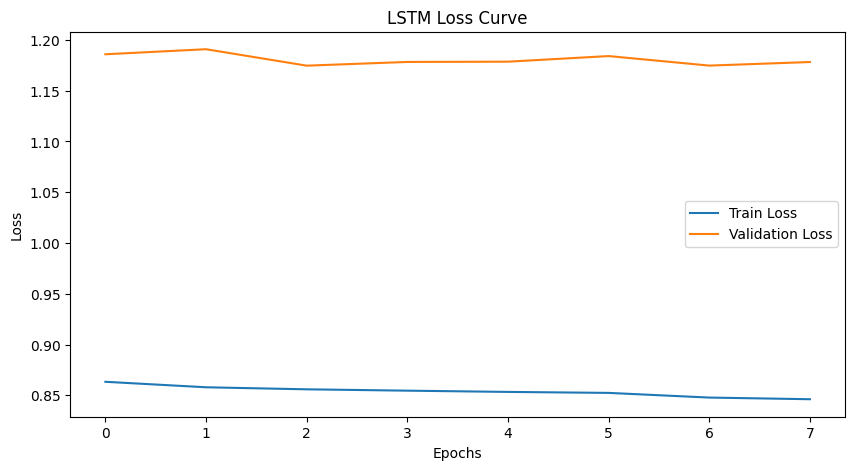

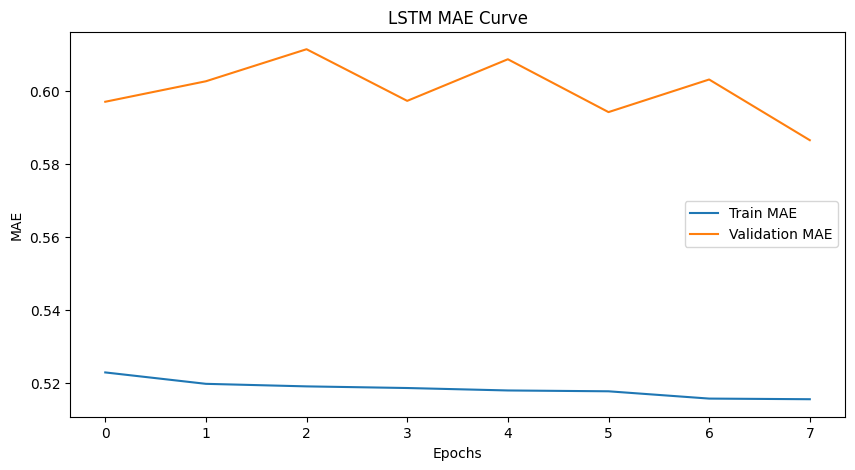


Model saved successfully ✔


In [ ]:
# ============================================================
# LSTM — AIRLINE DELAY PREDICTION 
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_parquet("../data/featured_data.parquet")

print("Dataset shape :", df.shape)
print(df.head())


# ============================================================
# BASIC CLEANING
# ============================================================

# Safe missing value handling (only existing delay columns)
delay_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

delay_cols = [col for col in delay_cols if col in df.columns]
df[delay_cols] = df[delay_cols].fillna(0)

df = df.dropna()

print("\nAfter cleaning :", df.shape)


# ============================================================
# CHRONOLOGICAL ORDER
# ============================================================

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("\nSorted chronologically ✔")


# ============================================================
# FEATURE SELECTION (REALISTIC FOR YOUR DATASET)
# ============================================================

# Target = departure_delay (most consistent in your dataset)
target_col = "departure_delay"

features = [
    target_col,
    "scheduled_elapsed_time",
    "departure_hour",
    "airport_traffic",
    "carrier_traffic",
    "is_peak_hour"
]

# Keep only existing columns (safe guard)
features = [col for col in features if col in df.columns]

data = df[features]

print("\nSelected features:", features)
print(data.head())


# ============================================================
# SCALING (IMPORTANT: avoid leakage → fit only on full here simplified)
# ============================================================

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


# ============================================================
# CREATE SEQUENCES
# ============================================================

SEQ_LENGTH = 10

X, y = [], []

for i in range(SEQ_LENGTH, len(scaled_data)):
    X.append(scaled_data[i - SEQ_LENGTH:i])
    y.append(scaled_data[i][0])  # target = first column (departure_delay)

X = np.array(X)
y = np.array(y)

print("\nSequences created ✔")
print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# TRAIN / VAL / TEST SPLIT (TIME SERIES STYLE)
# ============================================================

train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("\nSplit done ✔")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


# ============================================================
# LSTM MODEL
# ============================================================

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("\nModel Summary")
model.summary()


# ============================================================
# CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)


# ============================================================
# TRAINING
# ============================================================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n==========================")
print("LSTM RESULTS")
print("==========================")

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# ============================================================
# MAE CURVE
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("LSTM MAE Curve")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()


# ============================================================
# SAVE MODEL
# ============================================================

model.save("../models/lstm_model.keras")

print("\nModel saved successfully ✔")